In [3]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
newsgroups = fetch_20newsgroups(subset='all', remove=("headers", "footers", "quotes"))

In [5]:
tfidf_Vectorizer = TfidfVectorizer(max_df=0.5, max_features=1000, stop_words='english')
tfidf_matrix = tfidf_Vectorizer.fit_transform(newsgroups.data)

In [7]:
lsa = TruncatedSVD(n_components=2) # Latent Samentic Analysis (Dimensional Semantic Analysis)
lsa_matrix = lsa.fit_transform(tfidf_matrix)

In [9]:
k = 20
model = KMeans(n_clusters=k, init='k-means++', random_state=42)
model.fit(lsa_matrix)

KMeans(n_clusters=20, random_state=42)

In [17]:
labels = model.labels_
cluster_center = model.cluster_centers_

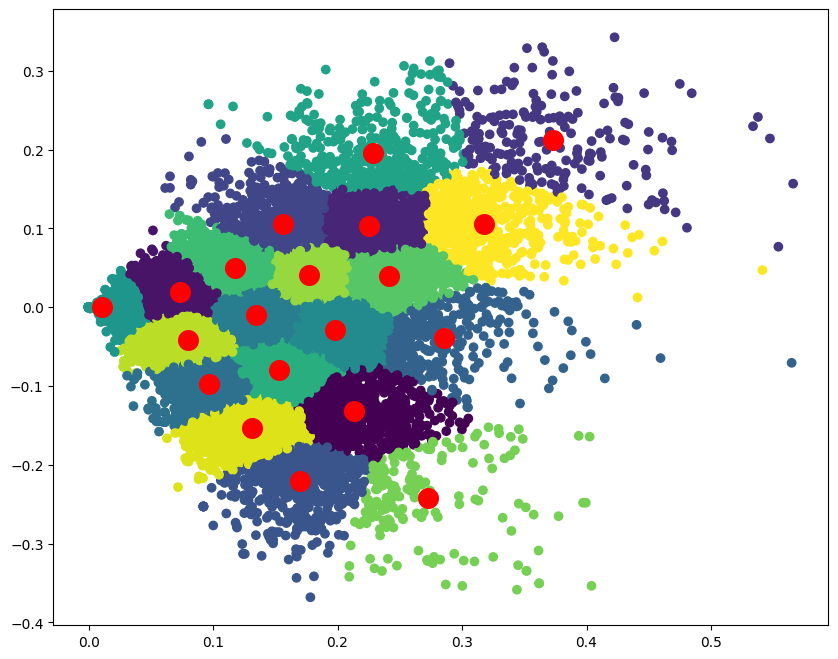

In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(lsa_matrix[:, 0] , lsa_matrix[:, 1], c=labels, cmap="viridis")
plt.scatter(cluster_center[:, 0], cluster_center[:, 1], s=200, c="red")